# AI-Powered E-Commerce Customer Intelligence

## Notebook 03 — Exploratory Data Analysis

### Objective

Notebook ini digunakan untuk menemukan pola dan hubungan bisnis
dalam dataset yang telah melalui data preparation.

### Business Questions

1. Bagaimana perkembangan revenue dari waktu ke waktu?
2. Produk dan kategori apa yang memberikan kontribusi terbesar?
3. Bagaimana distribusi customer berdasarkan purchase behavior?
4. Apakah terdapat perbedaan behavior antara churned dan active customers?
5. Bagaimana customer engagement melalui sessions berkaitan dengan
   conversion?
6. Apakah terdapat perbedaan performa antar negara?

### Important Principle

EDA digunakan untuk menemukan pola sebelum menentukan feature
engineering dan machine learning approach.

Visualisasi tidak hanya digunakan untuk membuat grafik, tetapi untuk
menjawab business questions.

## 1. Load Processed Data

### Tujuan

Memuat dataset hasil data preparation.

### Input

- `data/processed/completed_transactions.csv`
- `data/processed/transaction_analysis.csv`
- `data/processed/customer_analysis.csv`

Dataset ini digunakan sebagai analytical dataset sehingga kita tidak
perlu melakukan transformation raw data kembali.

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [19]:
PROCESSED_DIR = Path("../data/processed")
RAW_DIR = Path("../data/raw")

completed_transactions = pd.read_csv(
    PROCESSED_DIR / "completed_transactions.csv"
)

transaction_analysis = pd.read_csv(
    PROCESSED_DIR / "transaction_analysis.csv"
)

customer_analysis = pd.read_csv(
    PROCESSED_DIR / "customer_analysis.csv"
)

sessions = pd.read_csv(
    RAW_DIR / "sessions.csv"
)

completed_transactions["transaction_date"] = pd.to_datetime(
    completed_transactions["transaction_date"]
)

customer_analysis["signup_date"] = pd.to_datetime(
    customer_analysis["signup_date"]
)

customer_analysis["first_purchase_date"] = pd.to_datetime(
    customer_analysis["first_purchase_date"]
)

customer_analysis["last_purchase_date"] = pd.to_datetime(
    customer_analysis["last_purchase_date"]
)

sessions["session_date"] = pd.to_datetime(
    sessions["session_date"]
)

print("Completed transactions:", completed_transactions.shape)
print("Transaction analysis:", transaction_analysis.shape)
print("Customer analysis:", customer_analysis.shape)
print("Sessions:", sessions.shape)

Completed transactions: (68700, 13)
Transaction analysis: (68700, 23)
Customer analysis: (10000, 16)
Sessions: (80000, 10)


## 2. Revenue Overview

### Tujuan

Mengukur baseline revenue dari completed transactions.

### Metrics

- Total revenue
- Number of completed transactions
- Number of unique customers
- Average order value

### Business Definition

Revenue:

`SUM(total_amount)` dari transaksi dengan status `completed`.

Average Order Value (AOV):

`Total Revenue / Number of Completed Transactions`

### Alasan

Metric ini akan menjadi baseline untuk seluruh sales analysis.

In [20]:
total_revenue = completed_transactions["total_amount"].sum()
completed_orders = completed_transactions["transaction_id"].nunique()
unique_customers = completed_transactions["customer_id"].nunique()
average_order_value = completed_transactions["total_amount"].mean()

pd.set_option("display.float_format", "{:,.2f}".format)

revenue_summary = pd.DataFrame(
    {
        "metric": [
            "Total Revenue",
            "Completed Transactions",
            "Unique Customers",
            "Average Order Value",
        ],
        "value": [
            total_revenue,
            completed_orders,
            unique_customers,
            average_order_value,
        ],
    }
)

revenue_summary

,metric,value
0,Total Revenue,"5,443,248.04"
1,Completed Transactions,"68,700.00"
2,Unique Customers,"9,730.00"
3,Average Order Value,79.23


## 3. Monthly Sales Trend

### Tujuan

Menganalisis perubahan revenue dari waktu ke waktu.

### Method

Transaksi akan diagregasi berdasarkan bulan.

### Business Question

Apakah revenue:

- meningkat,
- menurun,
- stabil,
- atau memiliki pola seasonal?

### Relevance

Hasil analisis ini akan menentukan apakah sales forecasting
layak dijadikan bagian utama project.

In [21]:
monthly_sales = (
    completed_transactions
    .assign(
        month=completed_transactions["transaction_date"].dt.to_period("M")
    )
    .groupby("month")
    .agg(
        revenue=("total_amount", "sum"),
        transactions=("transaction_id", "nunique"),
        customers=("customer_id", "nunique"),
    )
    .reset_index()
)

monthly_sales["month"] = monthly_sales["month"].dt.to_timestamp()

monthly_sales.head()

,month,revenue,transactions,customers
0,2023-01-01,"193,223.43",2918,2442
1,2023-02-01,"160,583.68",2557,2187
2,2023-03-01,"193,348.74",2880,2368
3,2023-04-01,"208,252.22",2785,2352
4,2023-05-01,"227,271.32",3034,2516


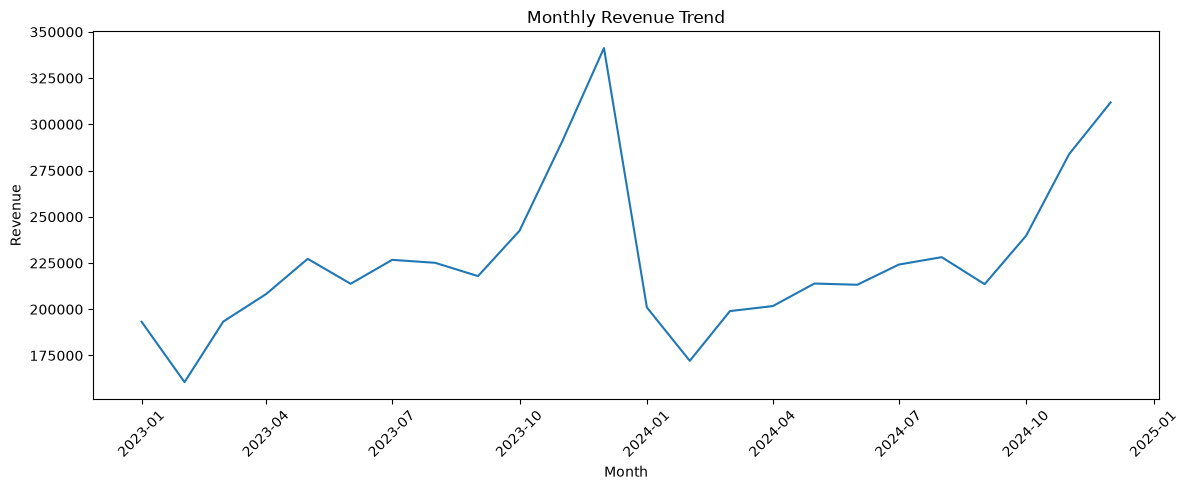

In [22]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="month",
    y="revenue",
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpretasi

Perhatikan:

- overall trend,
- peak month,
- lowest month,
- perubahan revenue,
- kemungkinan seasonal pattern.

Temuan dari grafik ini akan digunakan untuk menentukan pendekatan
sales forecasting pada tahap berikutnya.

## 4. Product Category Performance

### Tujuan

Mengidentifikasi kategori produk dengan kontribusi revenue terbesar.

### Metrics

- Revenue
- Transaction count
- Quantity sold

### Business Question

Kategori produk mana yang menjadi kontributor utama revenue?

In [23]:
category_performance = (
    transaction_analysis
    .groupby("category")
    .agg(
        revenue=("total_amount", "sum"),
        transactions=("transaction_id", "nunique"),
        quantity_sold=("quantity", "sum"),
    )
    .sort_values("revenue", ascending=False)
    .reset_index()
)

category_performance

,category,revenue,transactions,quantity_sold
0,Electronics,"1,504,492.02",5170,7634
1,Jewelry,"727,779.93",5003,7324
2,Automotive,"573,642.18",4658,6817
3,Home & Garden,"420,824.46",4652,6871
4,Sports,"362,736.17",5120,7503
5,Clothing,"337,762.07",4817,7022
6,Health,"332,018.22",6272,9195
7,Software,"275,158.57",3686,5450
8,Pet Supplies,"193,893.83",4761,7037
9,Toys,"157,511.03",4137,6109


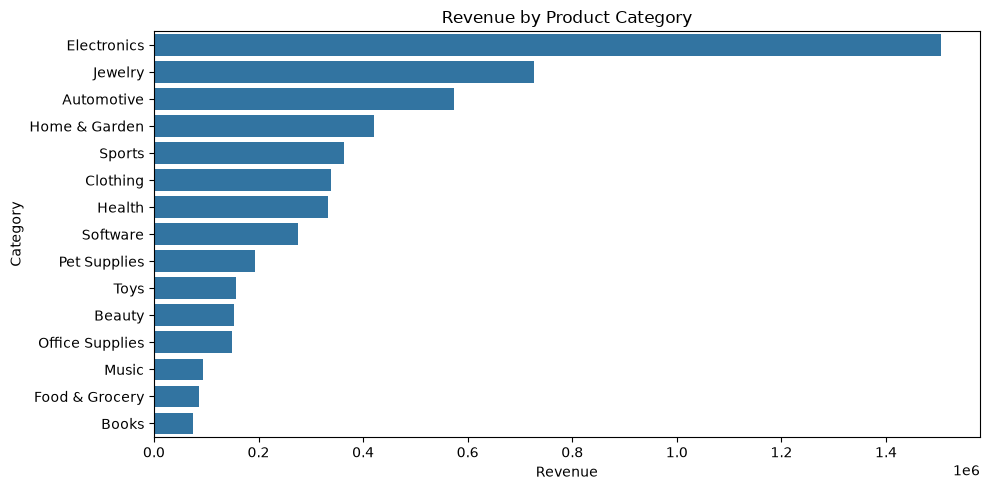

In [24]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=category_performance,
    x="revenue",
    y="category",
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## 5. Customer Revenue Distribution

### Tujuan

Memahami seberapa besar kontribusi revenue dari masing-masing customer.

### Metrics

- Total revenue
- Total orders
- Average order value

### Business Question

Apakah revenue terkonsentrasi pada sebagian kecil customer?

### Business Relevance

Jika revenue sangat terkonsentrasi, customer retention dan customer
prioritization dapat menjadi business problem yang penting.

In [25]:
customer_revenue = (
    customer_analysis[
        customer_analysis["total_revenue"].notna()
    ][
        [
            "customer_id",
            "total_orders",
            "total_revenue",
            "average_order_value",
            "is_churned",
        ]
    ]
    .sort_values("total_revenue", ascending=False)
)

customer_revenue.head(10)

,customer_id,total_orders,total_revenue,average_order_value,is_churned
3716,C03716,19.00,"7,346.46",386.66,0
7554,C07554,14.00,"7,068.11",504.87,0
3610,C03610,10.00,"5,771.96",577.20,0
2833,C02833,11.00,"4,704.00",427.64,1
5905,C05905,14.00,"4,400.88",314.35,0
369,C00369,26.00,"4,138.39",159.17,0
4273,C04273,21.00,"4,122.76",196.32,0
6839,C06839,15.00,"3,852.02",256.80,0
2598,C02598,18.00,"3,844.05",213.56,0
661,C00661,18.00,"3,782.69",210.15,0


## 6. Customer Churn vs Purchase Behavior

### Tujuan

Membandingkan customer yang churn dengan customer yang masih aktif.

### Metrics

- Total orders
- Total revenue
- Average order value

### Business Question

Apakah terdapat perbedaan purchase behavior antara churned dan
non-churned customers?

### Important

Analisis ini bersifat exploratory.

Kita belum menyimpulkan bahwa suatu variable menyebabkan churn.

In [26]:
churn_behavior = (
    customer_analysis
    .groupby("is_churned")
    .agg(
        customers=("customer_id", "nunique"),
        avg_orders=("total_orders", "mean"),
        avg_revenue=("total_revenue", "mean"),
        avg_order_value=("average_order_value", "mean"),
    )
    .reset_index()
)

churn_behavior

,is_churned,customers,avg_orders,avg_revenue,avg_order_value
0,0,8306,7.46,591.83,79.60
1,1,1694,5.04,394.56,79.10


## 7. Customer Segment Distribution

### Tujuan

Melihat distribusi customer berdasarkan segment yang tersedia
di dataset.

### Important

`segment` adalah atribut yang sudah diberikan oleh dataset.

Untuk analisis bisnis, variable ini dapat digunakan sebagai descriptive
attribute.

Namun untuk churn prediction, `segment` tidak langsung digunakan sebagai
feature sebelum leakage analysis selesai.

In [27]:
segment_distribution = (
    customer_analysis["segment"]
    .value_counts()
    .rename_axis("segment")
    .reset_index(name="customers")
)

segment_distribution["percentage"] = (
    segment_distribution["customers"]
    / segment_distribution["customers"].sum()
    * 100
)

segment_distribution

,segment,customers,percentage
0,Regular,3500,35.00
1,Budget Shopper,3043,30.43
2,Premium,1982,19.82
3,VIP,974,9.74
4,Occasional Visitor,501,5.01


## 8. Customer Engagement & Conversion

### Tujuan

Menganalisis hubungan antara aktivitas session dan conversion.

### Variables

- duration_seconds
- pages_viewed
- cart_additions
- converted
- bounced

### Business Question

Apakah customer dengan engagement lebih tinggi memiliki conversion
yang lebih tinggi?

### Business Relevance

Hasil ini dapat digunakan untuk memahami customer journey dan
menentukan potential feature untuk customer behavior analysis.

In [28]:
session_summary = (
    sessions
    .groupby("converted")
    .agg(
        sessions=("session_id", "count"),
        avg_duration=("duration_seconds", "mean"),
        avg_pages=("pages_viewed", "mean"),
        avg_cart_additions=("cart_additions", "mean"),
        avg_bounce_rate=("bounced", "mean"),
    )
    .reset_index()
)

session_summary

,converted,sessions,avg_duration,avg_pages,avg_cart_additions,avg_bounce_rate
0,0,71352,363.29,6.34,0.60,0.09
1,1,8648,440.66,7.70,2.99,0.07


## 9. Customer Geography

### Tujuan

Menganalisis customer berdasarkan country.

### Business Question

Apakah terdapat negara dengan:

- customer count tinggi,
- revenue tinggi,
- atau revenue per customer tinggi?

### Relevance

Analisis ini dapat membantu menentukan market prioritization.

In [29]:
country_analysis = (
    customer_analysis
    .groupby("country")
    .agg(
        customers=("customer_id", "nunique"),
        revenue=("total_revenue", "sum"),
        avg_revenue_per_customer=("total_revenue", "mean"),
    )
    .sort_values("revenue", ascending=False)
    .reset_index()
)

country_analysis

,country,customers,revenue,avg_revenue_per_customer
0,US,3933,"2,124,285.38",555.66
1,UK,1186,"675,408.99",585.78
2,CA,1032,"530,586.73",531.65
3,DE,760,"405,334.32",549.23
4,FR,614,"353,837.58",584.86
5,IN,603,"338,440.70",579.52
6,AU,618,"325,555.66",538.11
7,BR,529,"292,870.56",565.39
8,JP,433,"250,346.70",587.67
9,MX,292,"146,581.42",523.51


### Customer Revenue Concentration

#### Tujuan

Menganalisis seberapa besar kontribusi revenue yang berasal dari
sebagian kecil customer.

#### Method

Customer diurutkan berdasarkan total revenue secara descending.

Kemudian dihitung kontribusi revenue dari:

- Top 10% customers
- Top 20% customers
- Top 50% customers

#### Business Question

Apakah revenue tersebar secara merata di seluruh customer,
atau terdapat konsentrasi revenue pada sebagian customer?


In [30]:
customer_revenue = (
    customer_analysis[
        customer_analysis["total_revenue"].notna()
    ][
        ["customer_id", "total_revenue"]
    ]
    .sort_values(
        "total_revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

total_customer_revenue = customer_revenue["total_revenue"].sum()

n_customers = len(customer_revenue)

top_10_count = int(n_customers * 0.10)
top_20_count = int(n_customers * 0.20)
top_50_count = int(n_customers * 0.50)

top_10_revenue = (
    customer_revenue
    .iloc[:top_10_count]["total_revenue"]
    .sum()
)

top_20_revenue = (
    customer_revenue
    .iloc[:top_20_count]["total_revenue"]
    .sum()
)

top_50_revenue = (
    customer_revenue
    .iloc[:top_50_count]["total_revenue"]
    .sum()
)

concentration = pd.DataFrame(
    {
        "group": [
            "Top 10%",
            "Top 20%",
            "Top 50%",
        ],
        "customers": [
            top_10_count,
            top_20_count,
            top_50_count,
        ],
        "revenue": [
            top_10_revenue,
            top_20_revenue,
            top_50_revenue,
        ],
    }
)

concentration["revenue_share"] = (
    concentration["revenue"]
    / total_customer_revenue
    * 100
)

concentration

,group,customers,revenue,revenue_share
0,Top 10%,973,"1,657,560.95",30.45
1,Top 20%,1946,"2,652,669.44",48.73
2,Top 50%,4865,"4,440,003.61",81.57


## 10. Initial Business Insights

### Tujuan

Mendokumentasikan insight utama yang ditemukan dari hasil Exploratory Data Analysis (EDA).

Insight pada bagian ini hanya menggunakan hasil analysis yang telah dilakukan
pada notebook ini dan akan menjadi dasar untuk tahap feature engineering
dan machine learning.

### 1. Revenue Trend

Total revenue dari completed transactions mencapai sekitar **5.44 juta**
dengan **68,700 completed transactions** dan **9,730 unique customers**.

Monthly sales analysis menunjukkan bahwa revenue berubah dari bulan ke bulan.
Pola tersebut menjadi indikasi bahwa faktor waktu perlu dipertimbangkan
pada tahap sales forecasting.

### 2. Top Product Categories

**Electronics** merupakan kategori dengan revenue tertinggi, yaitu sekitar
**1.50 juta**, sehingga menjadi kategori utama dalam kontribusi revenue.

Kategori dengan revenue tinggi dapat menjadi prioritas untuk analysis lebih lanjut,
terutama dalam memahami customer behavior dan sales performance.

### 3. Customer Revenue Concentration

Revenue tidak tersebar secara merata di seluruh customer.

Hasil concentration analysis menunjukkan:

- Top 10% customers menghasilkan **30.45%** revenue.
- Top 20% customers menghasilkan **48.73%** revenue.
- Top 50% customers menghasilkan **81.57%** revenue.

Hal ini menunjukkan bahwa sebagian customer memiliki kontribusi yang jauh lebih
besar terhadap total revenue.

Temuan ini relevan untuk strategi customer retention karena kehilangan
customer bernilai tinggi berpotensi memberikan dampak yang lebih besar
terhadap revenue.

### 4. Difference Between Churned and Active Customers

Customer yang churn memiliki rata-rata:

- **5.04 orders**
- **394.56 revenue**

Sedangkan customer yang tidak churn memiliki rata-rata:

- **7.46 orders**
- **591.83 revenue**

Average Order Value relatif sama antara kedua kelompok, yaitu sekitar **79**.

Temuan ini menunjukkan bahwa perbedaan churn lebih terlihat pada frekuensi
pembelian dan total customer revenue dibandingkan nilai rata-rata setiap order.

Karena analysis ini bersifat exploratory, hubungan tersebut belum dapat dianggap
sebagai hubungan kausal.

### 5. Customer Engagement and Conversion Pattern

Session yang menghasilkan conversion memiliki engagement yang lebih tinggi.

Rata-rata converted session:

- Duration: **440.66 seconds**
- Pages viewed: **7.70**
- Cart additions: **2.99**

Sedangkan non-converted session:

- Duration: **363.29 seconds**
- Pages viewed: **6.34**
- Cart additions: **0.60**

Cart additions menunjukkan perbedaan yang paling besar antara converted dan
non-converted sessions.

Variabel engagement seperti session duration, pages viewed, dan cart additions
berpotensi digunakan sebagai customer-level features setelah dilakukan aggregation.

### 6. Country Performance

**United States** memiliki jumlah customer dan total revenue terbesar.

Namun, average revenue per customer tidak selalu mengikuti customer volume.
Beberapa market seperti **Japan, UK, dan France** menunjukkan average revenue
per customer yang relatif tinggi.

Hal ini menunjukkan bahwa market size dan customer value merupakan dua dimensi
yang berbeda dan dapat digunakan untuk market prioritization.

### 7. Potential Business Problems

Berdasarkan EDA, beberapa potential business problems yang dapat dianalisis
lebih lanjut adalah:

1. Customer churn dan penurunan purchase frequency.
2. Ketergantungan revenue pada customer bernilai tinggi.
3. Perbedaan customer behavior berdasarkan engagement.
4. Perbedaan customer value antar negara.
5. Perubahan revenue dari waktu ke waktu yang perlu dipahami untuk forecasting.

### 8. Potential Features for Machine Learning

Berdasarkan hasil EDA, beberapa candidate features untuk tahap machine learning
adalah:

#### Customer Behavior

- total_orders
- total_revenue
- average_order_value
- total_quantity
- customer purchase frequency
- recency
- customer tenure

#### Session Engagement

- total_sessions
- average_session_duration
- average_pages_viewed
- total_cart_additions
- conversion rate
- bounce rate

#### Customer Profile

- age
- gender
- country
- email_opt_in
- has_app

### Potential Data Leakage

Kolom **segment** tidak akan langsung digunakan sebagai feature untuk churn
prediction karena dataset generation menunjukkan bahwa segment memiliki hubungan
langsung dengan pembentukan target `is_churned`.

`lifetime_value` juga perlu dievaluasi secara temporal sebelum digunakan sebagai
feature agar model tidak memperoleh informasi yang berasal dari periode setelah
customer mengalami churn.

### Conclusion

EDA menunjukkan bahwa dataset memiliki beberapa pola bisnis yang dapat
dikembangkan menjadi machine learning problems.

Fokus utama tahap berikutnya adalah:

1. membangun customer-level features,
2. melakukan customer segmentation,
3. membangun churn prediction model,
4. mengevaluasi performa model,
5. menggunakan hasil model untuk menghasilkan business insights.